<a href="https://colab.research.google.com/github/2303a510B1/HPC-PROJECT/blob/main/PROJECT%20CODE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# performing clustering using traditional serial computation becomes inefficient and time-consuming.
Scenario: Customer Segmentation in an E-Commerce Platform

In modern digital businesses, especially large e-commerce platforms such as Amazon and Flipkart, companies deal with millions of customers daily.
Each customer generates a large amount of data through their purchasing behavior, browsing patterns, and spending habits.

To effectively utilize this data, businesses perform customer segmentation, which involves grouping customers based on similarities in their behavior.
One of the most widely used techniques for this purpose is K-Means Clustering, which groups customers into clusters such as high-value customers,
average customers, and low-engagement customers.

 # Problem Statement in Real Scenario

Consider an online retail company that wants to improve its marketing strategy.
The company has collected a dataset containing thousands of customers, where each customer is described by:

Annual Income
Spending Score

The goal is to divide customers into meaningful groups so that:

Premium customers receive exclusive offers
Regular customers receive personalized discounts
Low-engagement customers are targeted with promotional campaigns

However, as the number of customers increases to tens or hundreds of thousands,


In [1]:
%%writefile generate_customers.py
import random

limit = 10000

with open("customers.txt", "w") as f:
    for i in range(limit):
        income = random.randint(20000, 100000)
        spending = random.randint(1, 100)
        f.write(f"{income} {spending}\n")

print("customers.txt created")

Writing generate_customers.py


In [2]:
!python generate_customers.py

customers.txt created


In [3]:
!ls


customers.txt  generate_customers.py  sample_data


In [ ]:
%%writefile kmeans_threads.c
#include <stdio.h>
#include <stdlib.h>
#include <math.h>
#include <pthread.h>
#include <time.h>

#define MAX 20000
#define K 3
#define THREADS 4
#define ITER 10

float data[MAX][2];
float centroids[K][2];
int cluster[MAX];
int n = 0;

typedef struct {
    int start;
    int end;
} ThreadData;

float distance(float x1, float y1, float x2, float y2) {
    return sqrt((x1-x2)*(x1-x2) + (y1-y2)*(y1-y2));
}

void* assignCluster(void* arg) {
    ThreadData* d = (ThreadData*)arg;

    for(int i = d->start; i < d->end; i++) {
        float min = 1e9;
        int idx = 0;

        for(int j = 0; j < K; j++) {
            float dist = distance(data[i][0], data[i][1],
                                  centroids[j][0], centroids[j][1]);
            if(dist < min) {
                min = dist;
                idx = j;
            }
        }
        cluster[i] = idx;
    }
    return NULL;
}

int main() {

    FILE *fp = fopen("customers.txt","r");
    while(fscanf(fp,"%f %f",&data[n][0],&data[n][1]) != EOF) n++;
    fclose(fp);

    printf("Total Customers: %d\n", n);

    for(int i=0;i<K;i++){
        centroids[i][0] = data[i][0];
        centroids[i][1] = data[i][1];
    }

    int repeat = 5;

    // SERIAL
    clock_t s1 = clock();

    for(int r=0;r<repeat;r++){
        for(int i=0;i<n;i++){
            float min = 1e9;
            int idx = 0;

            for(int j=0;j<K;j++){
                float d = distance(data[i][0], data[i][1],
                                   centroids[j][0], centroids[j][1]);
                if(d < min){
                    min = d;
                    idx = j;
                }
            }
            cluster[i] = idx;
        }
    }

    clock_t e1 = clock();
    double serial = (double)(e1 - s1)/CLOCKS_PER_SEC;

    // PARALLEL
    double s2 = (double)clock()/CLOCKS_PER_SEC;

    for(int r=0;r<repeat;r++){
        pthread_t threads[THREADS];
        ThreadData d[THREADS];

        int chunk = n / THREADS;

        for(int i=0;i<THREADS;i++){
            d[i].start = i * chunk;
            d[i].end = (i==THREADS-1) ? n : (i+1)*chunk;

            pthread_create(&threads[i], NULL, assignCluster, &d[i]);
        }

        for(int i=0;i<THREADS;i++){
            pthread_join(threads[i], NULL);
        }
    }

    double e2 = (double)clock()/CLOCKS_PER_SEC;
    double parallel = e2 - s2;

    printf("Serial Time: %f sec\n", serial);
    printf("Parallel Time: %f sec\n", parallel);

    FILE *out = fopen("cpu_output.txt","w");
    fprintf(out,"%f %f",serial,parallel);
    fclose(out);

    return 0;
}

In [5]:
!gcc kmeans_threads.c -o kmeans_threads -lm -lpthread
!./kmeans_threads

Total Customers: 10000
Serial Time: 0.002818 sec
Parallel Time: 0.001533 sec



FINAL RESULT
Serial   : 0.002818 sec
Parallel : 0.001533 sec


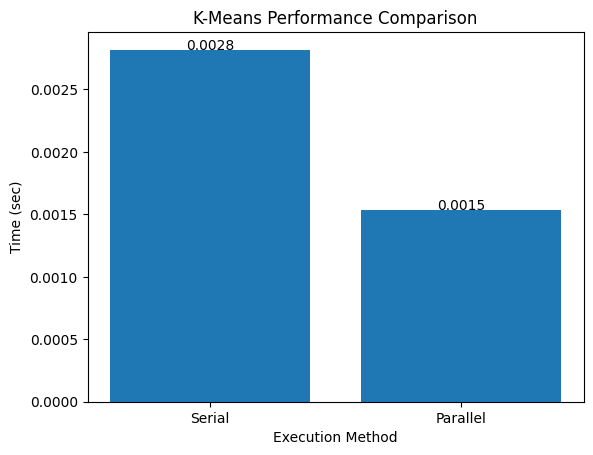

In [6]:
import matplotlib.pyplot as plt

with open("cpu_output.txt") as f:
    serial, parallel = map(float, f.read().split())

print("\nFINAL RESULT")
print("Serial   :", serial, "sec")
print("Parallel :", parallel, "sec")

methods = ['Serial', 'Parallel']
times = [serial, parallel]

plt.figure()
plt.bar(methods, times)

for i, v in enumerate(times):
    plt.text(i, v, f"{v:.4f}", ha='center')

plt.title("K-Means Performance Comparison")
plt.ylabel("Time (sec)")
plt.xlabel("Execution Method")

plt.show()